In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy import stats

In [2]:
os.chdir('phase1_acc_occ')
n_sub = len(os.listdir())
accuracies = []
for file in os.listdir():
    sub_acc = np.load(file)
    sub_acc_mean = np.mean(sub_acc, axis = 0)
    accuracies.append(sub_acc_mean)

os.chdir('../phase1_acc_occ_f')
accuracies_f = []
for file in os.listdir():
    sub_acc = np.load(file)
    sub_acc_mean = np.mean(sub_acc, axis = 0)
    accuracies_f.append(sub_acc_mean)

os.chdir('../phase1_acc_occ_inf')
accuracies_inf = []
for file in os.listdir():
    sub_acc = np.load(file)
    sub_acc_mean = np.mean(sub_acc, axis = 0)
    accuracies_inf.append(sub_acc_mean)

os.chdir('../')
print(f'number of subjects: {n_sub}')

number of subjects: 35


In [3]:
mean = np.mean(accuracies, axis = 0)
std = np.std(accuracies, axis = 0, ddof=1)
sem = std / np.sqrt(n_sub)

mean_f = np.mean(accuracies_f, axis = 0)
std_f = np.std(accuracies_f, axis = 0, ddof=1)
sem_f = std_f / np.sqrt(n_sub)

mean_inf = np.mean(accuracies_inf, axis = 0)
std_inf = np.std(accuracies_inf, axis = 0, ddof=1)
sem_inf = std_inf / np.sqrt(n_sub)

In [4]:
accuracies = np.array(accuracies)
accuracies_f = np.array(accuracies_f)
accuracies_inf = np.array(accuracies_inf)

t_stats = []
p_values = []

for tp in range(len(mean)):
    t, p = stats.ttest_rel(accuracies_f[:, tp], accuracies_inf[:, tp])
    t_stats.append(t)
    p_values.append(p)

t_stats = np.array(t_stats)
p_values = np.array(p_values)

sig_mask = p_values < 0.05

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


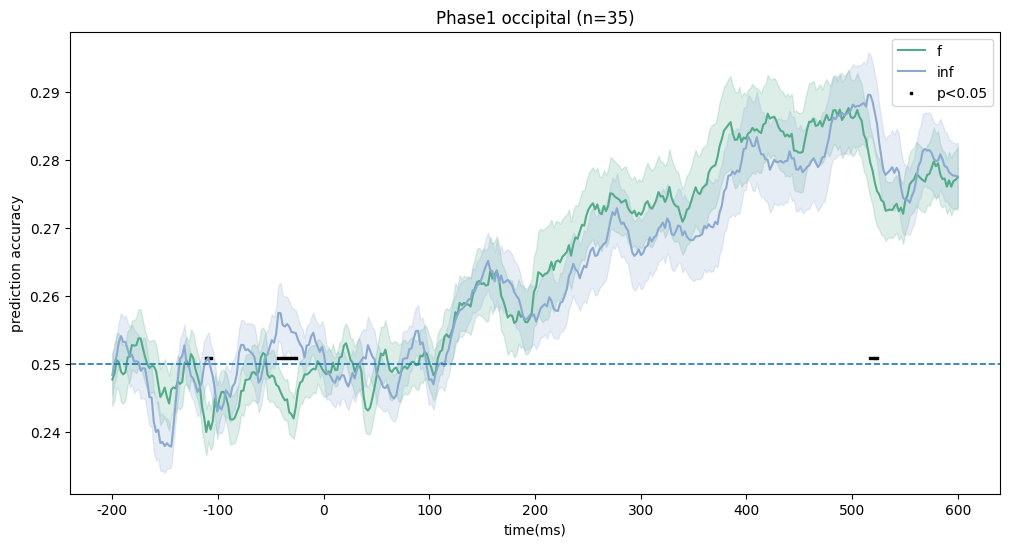

In [5]:
plt.figure(figsize=(12, 6))
x = np.arange(len(mean))
# plt.plot(x, mean, label = 'overall', color = '#C588BA')
# plt.fill_between(x, mean - sem, mean + sem, alpha=0.2, color = '#C588BA')

plt.plot(x, mean_f, label = 'f', color = '#52AC89')
plt.fill_between(x, mean_f - sem_f, mean_f + sem_f, alpha=0.2, color = '#52AC89')

plt.plot(x, mean_inf, label = 'inf', color = '#89A9D1')
plt.fill_between(x, mean_inf - sem_inf, mean_inf + sem_inf, alpha=0.2, color = '#89A9D1')

plt.axhline(0.25, linestyle='--',linewidth=1.2)

n_points = len(accuracies[0])
tick_positions = np.linspace(0, n_points-1, 9)
tick_labels = np.linspace(-200, 600, 9).astype(int)
plt.xticks(tick_positions, tick_labels)

y_position = plt.gca().get_ylim()[0] + 0.02
plt.scatter(x[sig_mask], np.ones(sig_mask.sum()) * y_position, 
            marker='s', s=2, color='black', label='p<0.05')

plt.xlabel('time(ms)')
plt.ylabel('prediction accuracy')
plt.title(f'Phase1 occipital (n={n_sub})')

plt.legend()
plt.savefig('Phase1 occipital.eps', format='eps', bbox_inches='tight');

C:\Users\dartuser\AppData\Local\Temp\ipykernel_33824\3499881756.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 4))


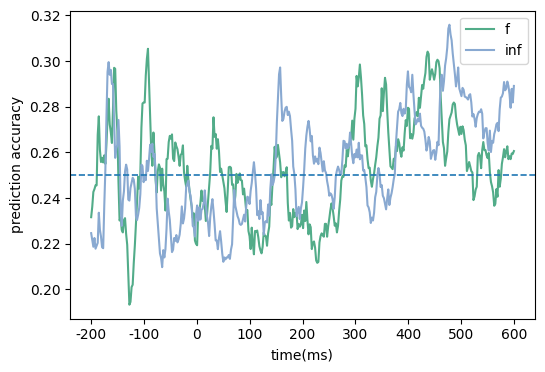

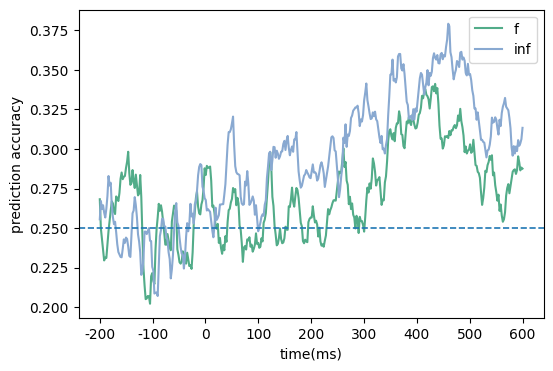

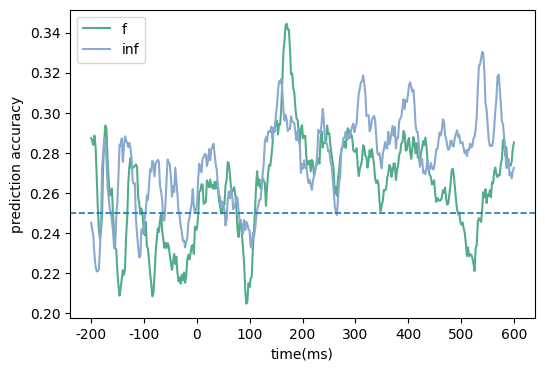

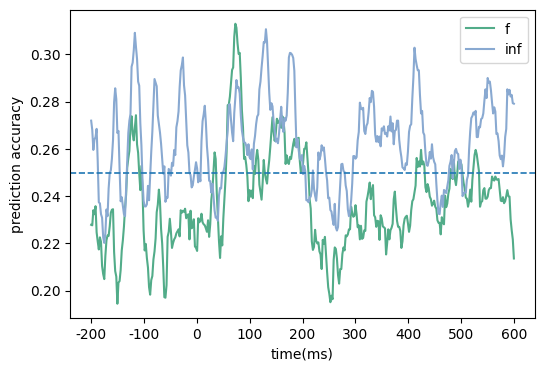

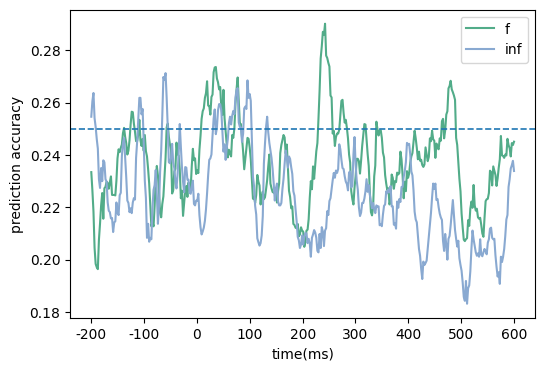

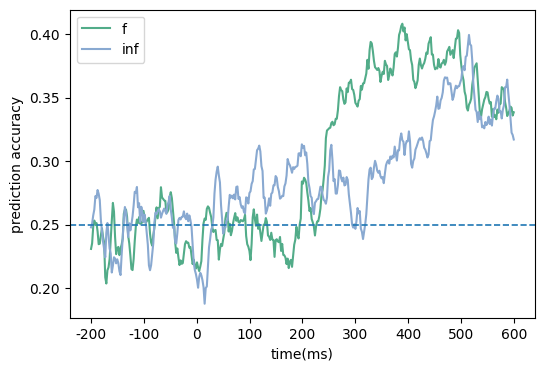

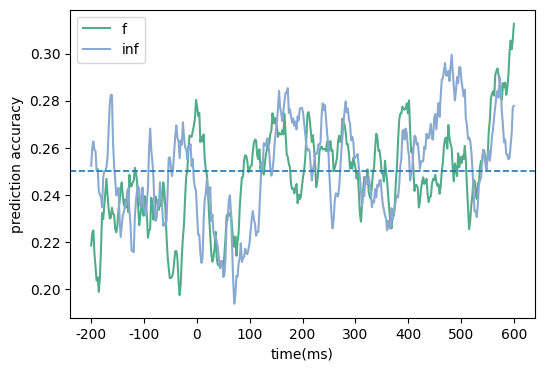

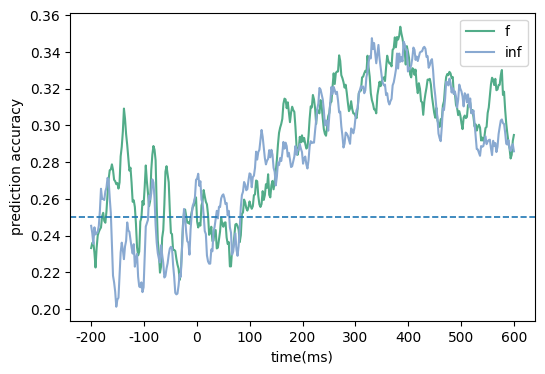

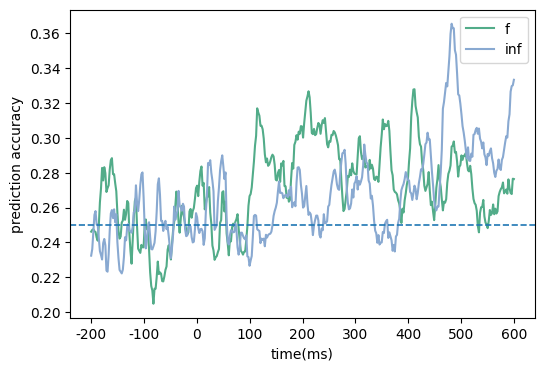

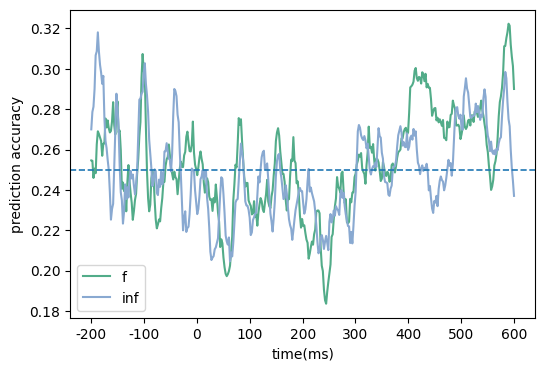

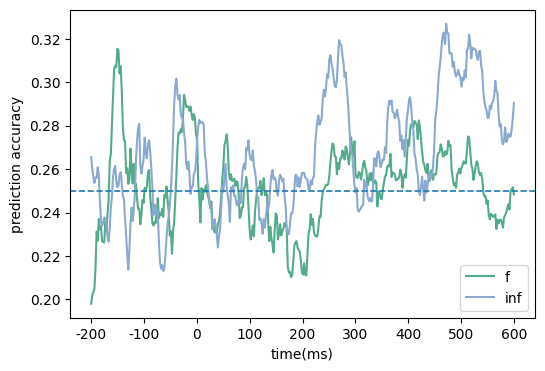

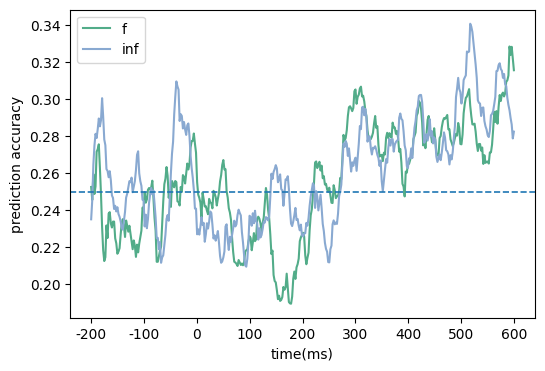

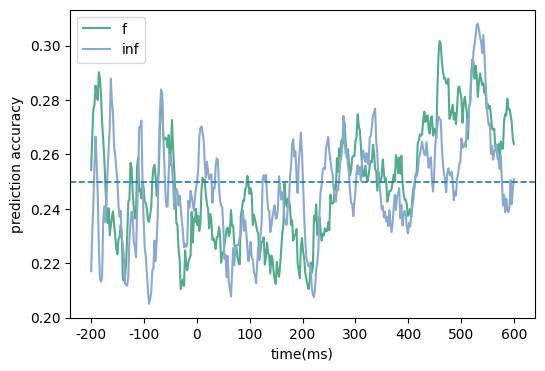

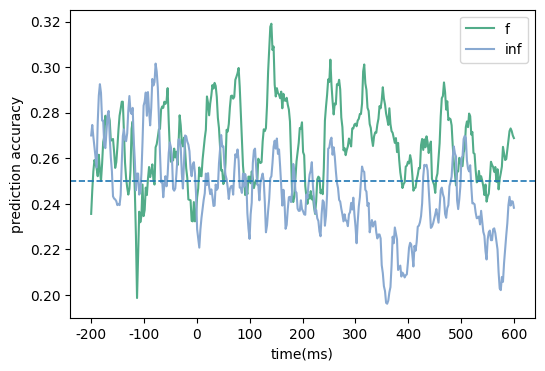

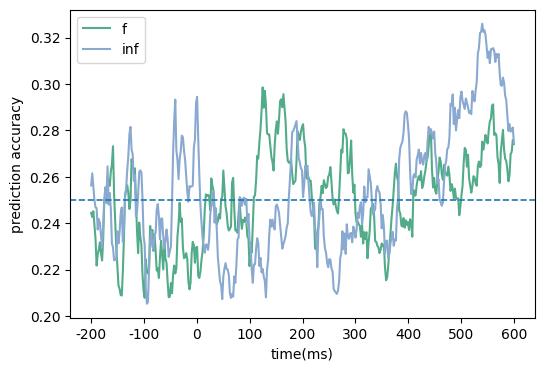

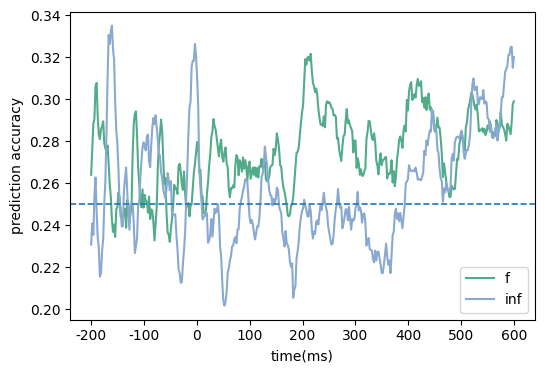

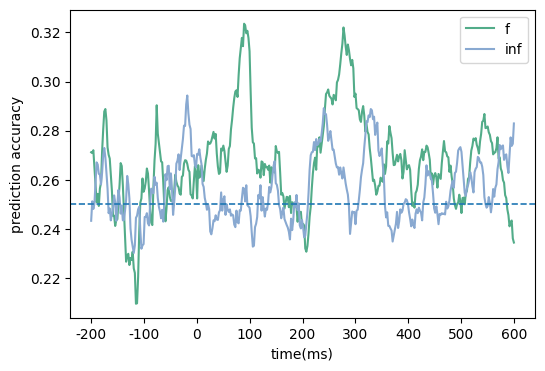

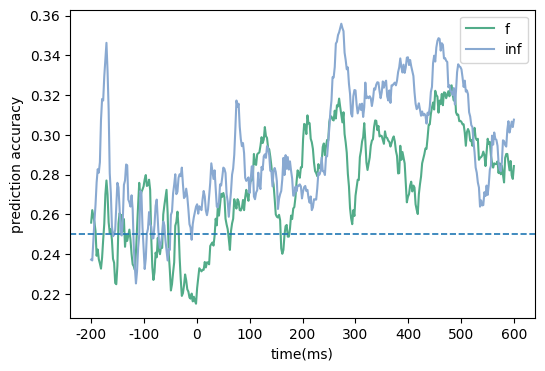

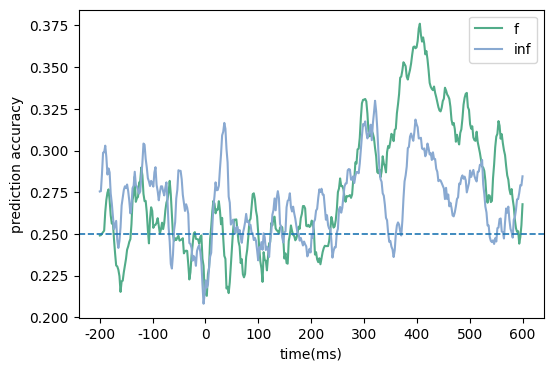

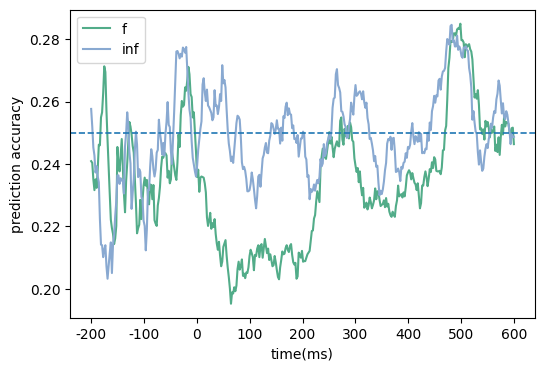

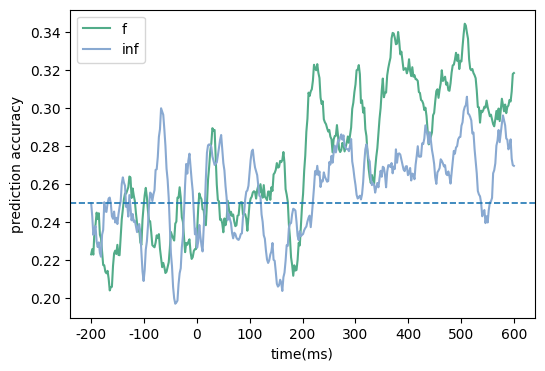

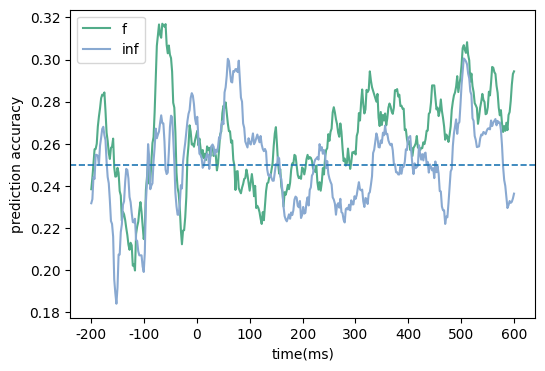

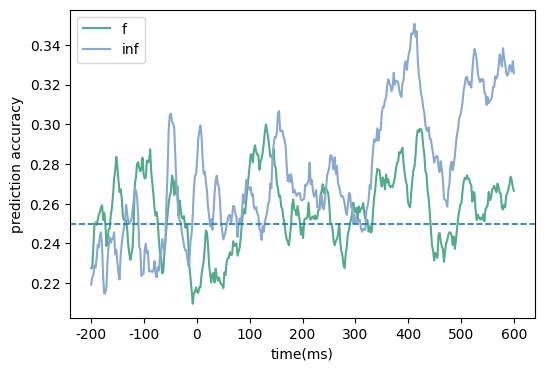

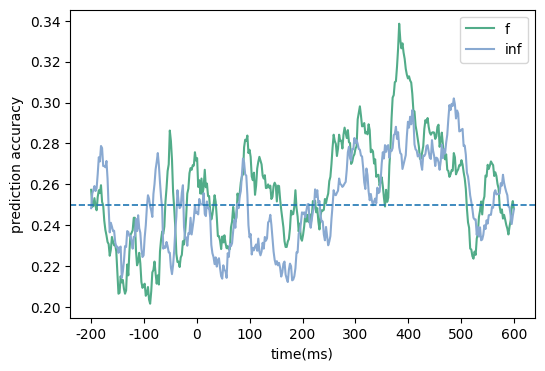

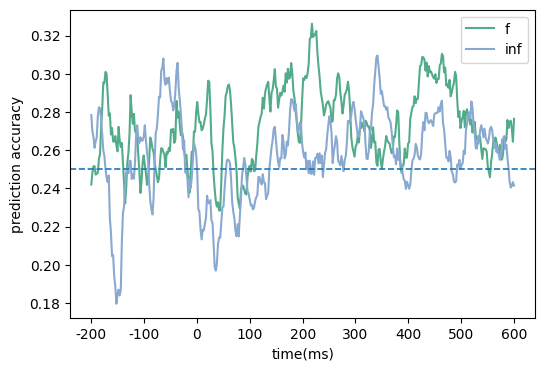

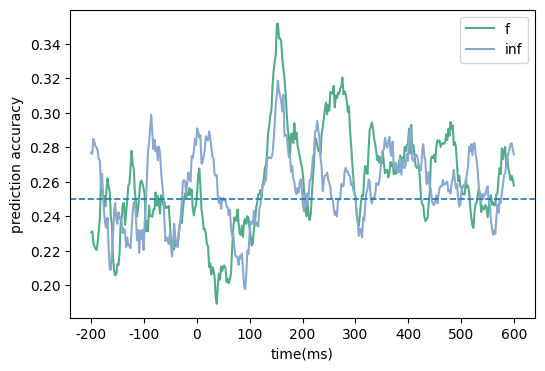

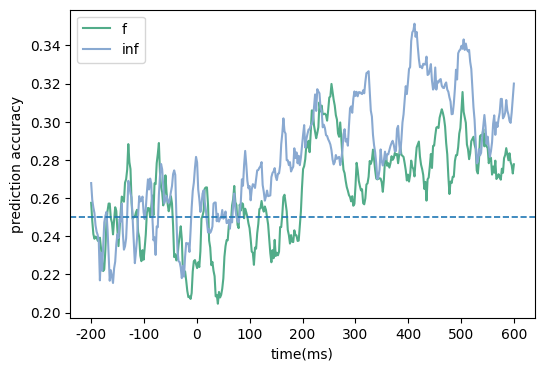

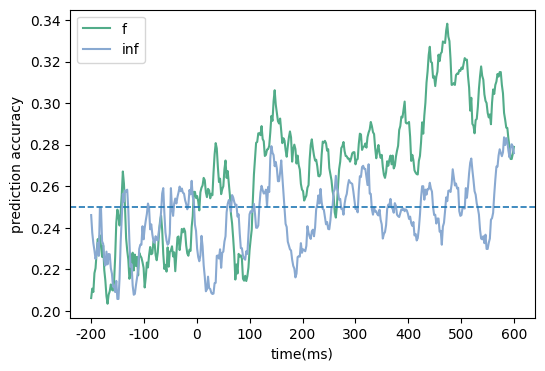

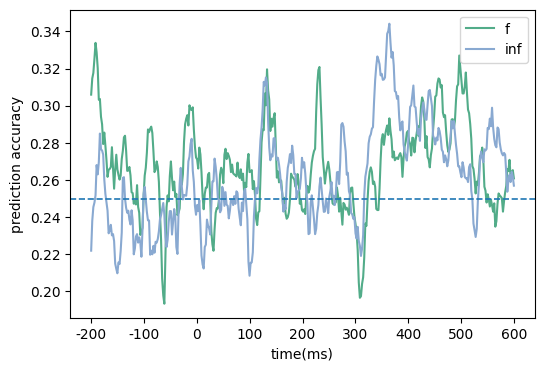

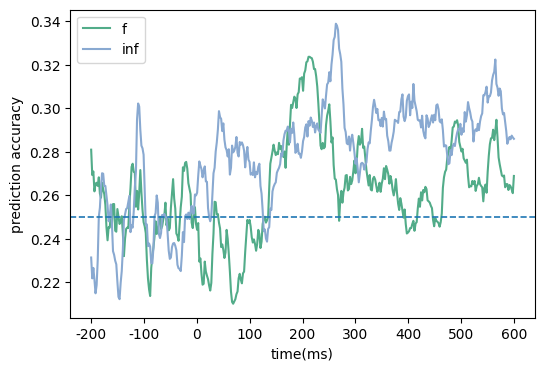

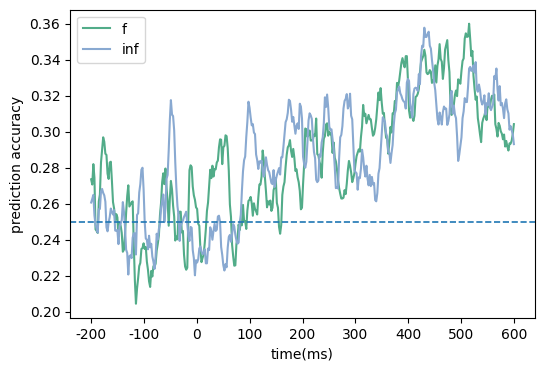

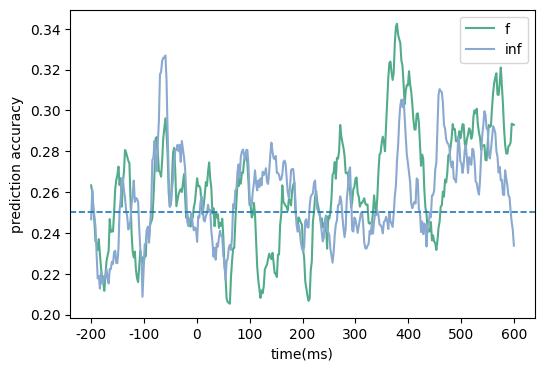

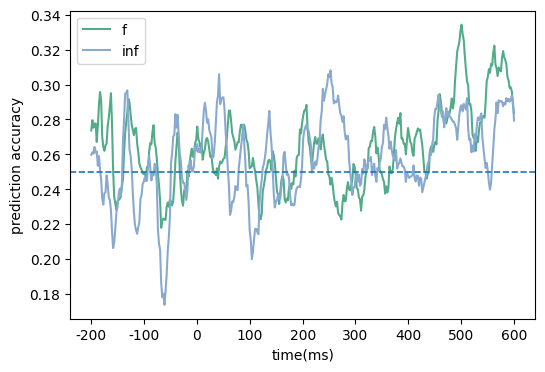

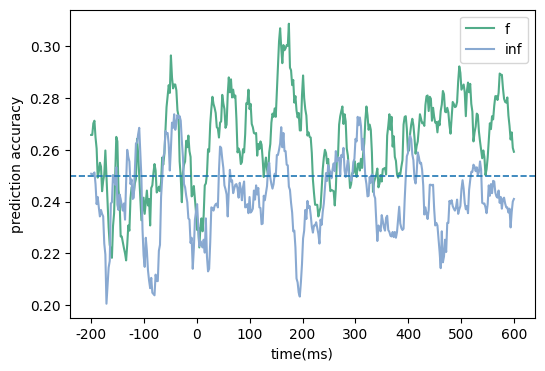

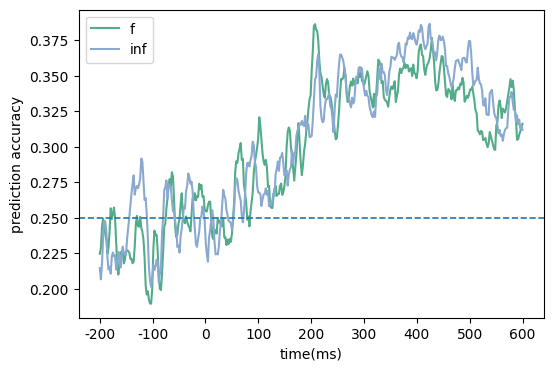

In [6]:
for sub in range(n_sub):
    plt.figure(figsize=(6, 4))
    plt.plot(x, accuracies_f[sub], label = 'f', color = '#52AC89')
    plt.plot(x, accuracies_inf[sub], label = 'inf', color = '#89A9D1')
    plt.axhline(0.25, linestyle='--',linewidth=1.2)
    n_points = len(accuracies[0])
    tick_positions = np.linspace(0, n_points-1, 9)
    tick_labels = np.linspace(-200, 600, 9).astype(int)
    plt.xticks(tick_positions, tick_labels)
    plt.xlabel('time(ms)')
    plt.ylabel('prediction accuracy')
    plt.legend();